In [1]:
!pip install textblob

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from textblob import TextBlob

In [8]:
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print(df.head())

Saving telco_churn_with_all_feedback.csv to telco_churn_with_all_feedback.csv
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... StreamingTV  \
0  No phone service             DSL             No  ...          No   
1                No             DSL            Yes  ...          No   
2                No             DSL            Yes  ...          No   
3  No phone service             DSL            Yes  ...          No   
4                No     Fiber optic             No  ...          No   

  StreamingMov

In [12]:
df = df[[
    "customerID",
    "gender",
    "InternetService",
    "Contract",
    "tenure",
    "MonthlyCharges",
    "Churn",
    "CustomerFeedback"
]].copy()

df = df.dropna(subset=["CustomerFeedback"])
df["CustomerFeedback"] = df["CustomerFeedback"].astype(str).str.strip()
df = df[df["CustomerFeedback"] != ""]

print("Rows after cleaning empty feedback:", len(df))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\\S+", "", text)
    text = re.sub(r"@\\w+", "", text)
    text = re.sub(r"[^a-zA-Z\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text

df["clean_text"] = df["CustomerFeedback"].apply(clean_text)
print(df.head())

Rows after cleaning empty feedback: 7043
   customerID  gender InternetService        Contract  tenure  MonthlyCharges  \
0  7590-VHVEG  Female             DSL  Month-to-month       1           29.85   
1  5575-GNVDE    Male             DSL        One year      34           56.95   
2  3668-QPYBK    Male             DSL  Month-to-month       2           53.85   
3  7795-CFOCW    Male             DSL        One year      45           42.30   
4  9237-HQITU  Female     Fiber optic  Month-to-month       2           70.70   

  Churn                                   CustomerFeedback  \
0    No  I have been using the DSL internet service fro...   
1    No  I have been a customer with this company for o...   
2   Yes  I recently signed up for DSL internet service ...   
3    No  I have been a loyal customer with this company...   
4   Yes  I recently switched to this fiber optic intern...   

                                          clean_text  
0  i have been using the dsl internet servic

In [13]:
def get_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity

    if polarity > 0.1:
        sentiment = "Positive"
    elif polarity < -0.1:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    return pd.Series([polarity, subjectivity, sentiment])


In [14]:
df[["polarity", "subjectivity", "sentiment"]] = df["clean_text"].apply(get_sentiment)

In [15]:
print("\n------ OVERALL SUMMARY -----")
print("Total feedback:", len(df))

print("\nSentiment counts:")
print(df["sentiment"].value_counts())

print("\nSentiment percentages:")
print((df["sentiment"].value_counts(normalize=True) * 100).round(2))

print("\nAverage polarity:", round(df["polarity"].mean(), 3))
print("Average subjectivity:", round(df["subjectivity"].mean(), 3))



------ OVERALL SUMMARY -----
Total feedback: 7043

Sentiment counts:
sentiment
Positive    5387
Neutral     1437
Negative     219
Name: count, dtype: int64

Sentiment percentages:
sentiment
Positive    76.49
Neutral     20.40
Negative     3.11
Name: proportion, dtype: float64

Average polarity: 0.178
Average subjectivity: 0.583


In [16]:
print("\n===== SENTIMENT BY CHURN =====")
print(pd.crosstab(df["Churn"], df["sentiment"]))

print("\nPercentage by churn:")
print((pd.crosstab(df["Churn"], df["sentiment"], normalize="index") * 100).round(2))


===== SENTIMENT BY CHURN =====
sentiment  Negative  Neutral  Positive
Churn                                 
No                2      593      4579
Yes             217      844       808

Percentage by churn:
sentiment  Negative  Neutral  Positive
Churn                                 
No             0.04    11.46     88.50
Yes           11.61    45.16     43.23


In [17]:
print("\n===== SENTIMENT BY SERVICE TYPE =====")
print(pd.crosstab(df["InternetService"], df["sentiment"]))

print("\nPercentage by service type:")
print((pd.crosstab(df["InternetService"], df["sentiment"], normalize="index") * 100).round(2))


===== SENTIMENT BY SERVICE TYPE =====
sentiment        Negative  Neutral  Positive
InternetService                             
DSL                   115      531      1775
Fiber optic            46      645      2405
No                     58      261      1207

Percentage by service type:
sentiment        Negative  Neutral  Positive
InternetService                             
DSL                  4.75    21.93     73.32
Fiber optic          1.49    20.83     77.68
No                   3.80    17.10     79.10


In [18]:
print("\n===== SENTIMENT BY GENDER =====")
print(pd.crosstab(df["gender"], df["sentiment"]))



===== SENTIMENT BY GENDER =====
sentiment  Negative  Neutral  Positive
gender                                
Female          101      708      2679
Male            118      729      2708


In [19]:
print("\n===== TOP 3 MOST NEGATIVE REVIEWS =====")
top_negative = df.sort_values("polarity").head(3)

for i, row in top_negative.iterrows():
    print("\nCustomer ID:", row["customerID"])
    print("Service Type:", row["InternetService"])
    print("Churn:", row["Churn"])
    print("Polarity:", round(row["polarity"], 3))
    print("Feedback:", row["CustomerFeedback"])



===== TOP 3 MOST NEGATIVE REVIEWS =====

Customer ID: 9564-KCLHR
Service Type: DSL
Churn: Yes
Polarity: -0.312
Feedback: I recently signed up for DSL internet service with this provider on a month-to-month contract. However, after just one month, I decided to cancel due to subpar connection speeds and unreliable service. Despite the affordable monthly charges of $51.25, I found that the service did not meet my expectations. Additionally, having to pay by mailing a check was inconvenient and outdated. Overall, I was disappointed with my experience and would not recommend this provider to others.

Customer ID: 6635-MYYYZ
Service Type: DSL
Churn: Yes
Polarity: -0.31
Feedback: I have been a customer with this DSL internet provider for 30 months now, but unfortunately, I have decided to churn. Despite being on a one-year contract with monthly charges of $85.35, I have found that the service does not meet my needs and expectations. The internet connection is often slow and unreliable, causi

In [20]:
print("\n===== TOP 3 MOST POSITIVE REVIEWS =====")
top_positive = df.sort_values("polarity", ascending=False).head(3)

for i, row in top_positive.iterrows():
    print("\nCustomer ID:", row["customerID"])
    print("Service Type:", row["InternetService"])
    print("Churn:", row["Churn"])
    print("Polarity:", round(row["polarity"], 3))
    print("Feedback:", row["CustomerFeedback"])


===== TOP 3 MOST POSITIVE REVIEWS =====

Customer ID: 9795-VOWON
Service Type: DSL
Churn: No
Polarity: 0.725
Feedback: I have been a customer with this DSL internet service provider for 7 months now and I am very satisfied with the service. The monthly charges of $24.35 are affordable and the automatic credit card payment method makes it convenient for me to pay my bills on time. The internet service has been reliable with no issues of churn. I am happy with my decision to sign a one year contract with this provider.

Customer ID: 1397-XKKWR
Service Type: DSL
Churn: No
Polarity: 0.65
Feedback: I have been a customer with this internet service provider for 7 months now and have been satisfied with their DSL internet service. The monthly charges of $35.3 are affordable and the payment method of mailing a check works well for me. I am happy to say that I have no plans to churn and will continue to be a customer for the remainder of my one-year contract.

Customer ID: 4795-WRNVT
Service T

In [24]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, 36, 72],
    labels=["0-6", "7-12", "13-24", "25-36", "37+"]
)

print("\n===== AVERAGE POLARITY BY TENURE =====")
print(df.groupby("tenure_group")["polarity"].mean().round(3))



===== AVERAGE POLARITY BY TENURE =====
tenure_group
0-6      0.097
7-12     0.174
13-24    0.185
25-36    0.182
37+      0.215
Name: polarity, dtype: float64


/tmp/ipykernel_7550/2442756621.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("tenure_group")["polarity"].mean().round(3))


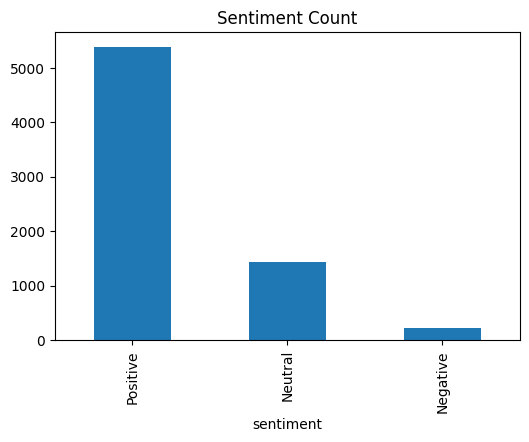

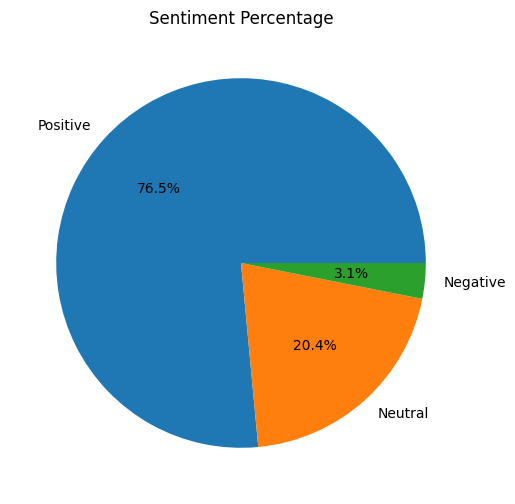

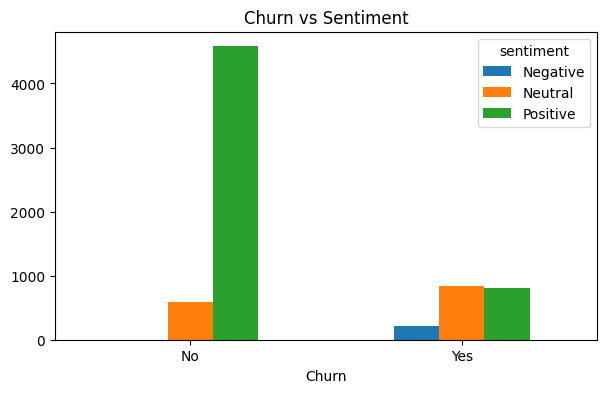

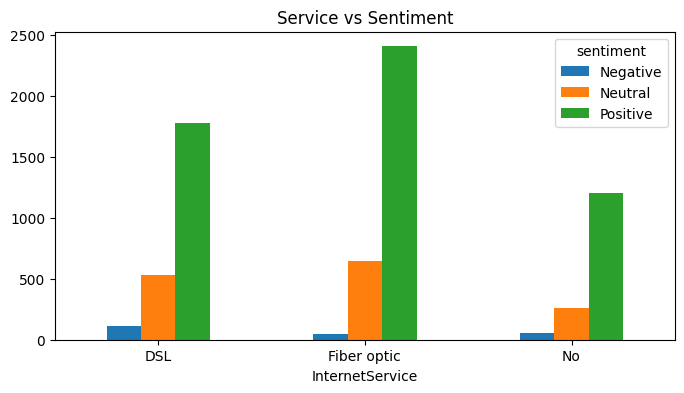

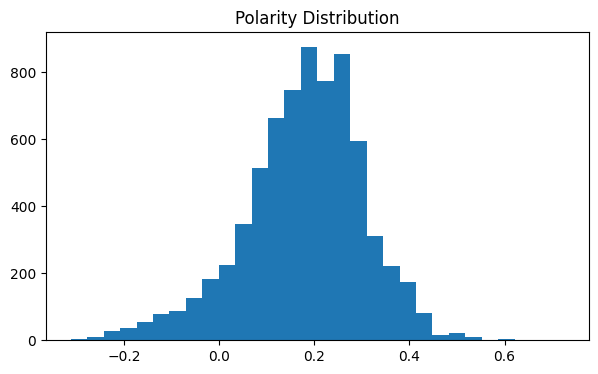

/tmp/ipykernel_7550/2338173151.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("tenure_group")["polarity"].mean().plot(kind="bar", figsize=(7,4))


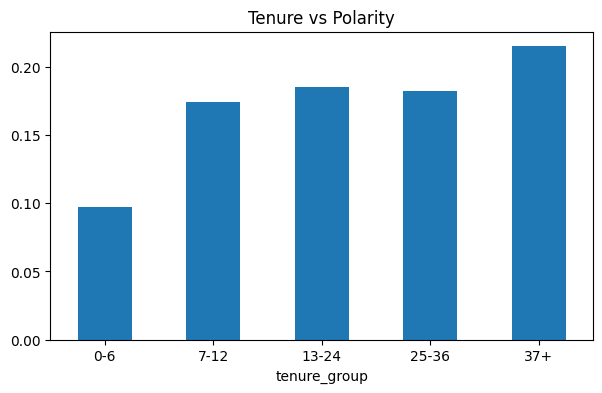


Saved: sentiment_results.csv


In [22]:
# Bar chart
plt.figure(figsize=(6,4))
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Count")
plt.show()

# Pie chart
plt.figure(figsize=(6,6))
df["sentiment"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Sentiment Percentage")
plt.ylabel("")
plt.show()

# Churn vs sentiment
pd.crosstab(df["Churn"], df["sentiment"]).plot(kind="bar", figsize=(7,4))
plt.title("Churn vs Sentiment")
plt.xticks(rotation=0)
plt.show()

# Service vs sentiment
pd.crosstab(df["InternetService"], df["sentiment"]).plot(kind="bar", figsize=(8,4))
plt.title("Service vs Sentiment")
plt.xticks(rotation=0)
plt.show()

# Polarity distribution
plt.figure(figsize=(7,4))
plt.hist(df["polarity"], bins=30)
plt.title("Polarity Distribution")
plt.show()

# Tenure vs polarity
df.groupby("tenure_group")["polarity"].mean().plot(kind="bar", figsize=(7,4))
plt.title("Tenure vs Polarity")
plt.xticks(rotation=0)
plt.show()

# STEP 17: Save output
df.to_csv("sentiment_results.csv", index=False)

print("\nSaved: sentiment_results.csv")